Не найдены в датасете: ['SEVEN']
ТОП-20 рекомендаций:


,movieId,title,year,genres
196,198,Strange Days,1995,"[Action, Crime, Drama, Mystery, Sci-Fi, Thriller]"
515,519,RoboCop 3,1993,"[Action, Crime, Drama, Sci-Fi, Thriller]"
1365,1396,Sneakers,1992,"[Action, Comedy, Crime, Drama, Sci-Fi]"
2900,2985,RoboCop,1987,"[Action, Crime, Drama, Sci-Fi, Thriller]"
4625,4719,Osmosis Jones,2001,"[Action, Animation, Comedy, Crime, Drama, Roma..."
4923,5018,Motorama,1991,"[Adventure, Comedy, Crime, Drama, Fantasy, Mys..."
9000,26701,Patlabor: The Movie (Kidô keisatsu patorebâ: T...,1989,"[Action, Animation, Crime, Drama, Film-Noir, M..."
10427,37462,Wedlock,1991,"[Action, Crime, Drama, Sci-Fi, Thriller]"
11494,49530,Blood Diamond,2006,"[Action, Adventure, Crime, Drama, Thriller, War]"
12720,59844,"Honor Among Thieves (Adieu l'ami) (Farewell, F...",1968,"[Action, Adventure, Crime, Drama, Mystery, Thr..."


Таблица замеров времени:


,n_movies,mean_ms,std_ms
0,3,25.625495,1.101890
1,5,27.255078,1.655177
2,8,26.973518,1.841202
3,10,26.284242,1.057476
4,12,26.647212,1.071115
5,15,28.474197,1.511012
6,20,25.616870,0.677886


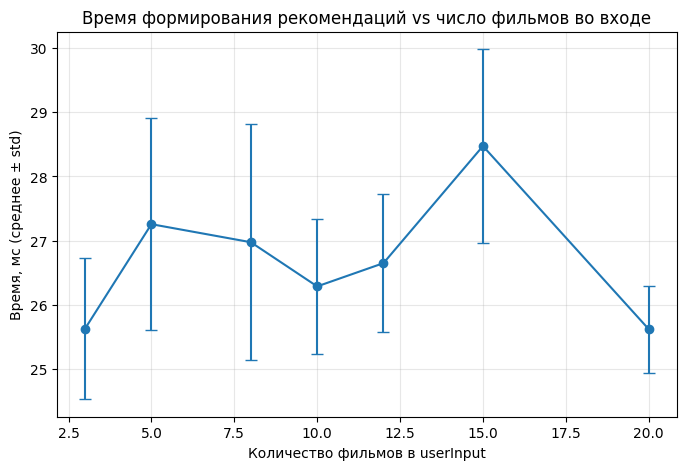

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

movies_df = pd.read_csv('/home/jupyter/work/data/movies.csv')
ratings_df = pd.read_csv('/home/jupyter/work/data/ratings.csv')

movies_df['year'] = movies_df['title'].str.extract(r'(\(\d{4}\))', expand=False)
movies_df['year'] = movies_df['year'].str.extract(r'(\d{4})', expand=False)
movies_df['title'] = movies_df['title'].str.replace(r'(\(\d{4}\))', '', regex=True).str.strip()
movies_df['genres'] = movies_df['genres'].str.split('|')


movies_df['title_norm'] = movies_df['title'].str.upper().str.strip()

ratings_df = ratings_df.drop(['timestamp'], axis=1)

moviesWithGenres_df = movies_df.copy()
for index, row in movies_df.iterrows():
    for genre in row['genres']:
        moviesWithGenres_df.at[index, genre] = 1
moviesWithGenres_df = moviesWithGenres_df.fillna(0)

userInput = [
    {'title':'BREAKFAST CLUB, THE', 'rating':5.0},
    {'title':'TOY STORY', 'rating':3.5},
    {'title':'JUMANJI', 'rating':2.0},
    {'title':'PULP FICTION', 'rating':5.0},
    {'title':'AKIRA', 'rating':4.5},
    {'title':'MATRIX, THE', 'rating':5.0},
    {'title':'GODFATHER, THE', 'rating':5.0},
    {'title':'DARK KNIGHT, THE', 'rating':4.8},
    {'title':'INCEPTION', 'rating':4.7},
    {'title':'FIGHT CLUB', 'rating':4.9},
    {'title':'FORREST GUMP', 'rating':4.6},
    {'title':'SHAWSHANK REDEMPTION, THE', 'rating':5.0},
    {'title':'LORD OF THE RINGS: THE FELLOWSHIP OF THE RING, THE', 'rating':4.8},
    {'title':'STAR WARS: EPISODE IV - A NEW HOPE', 'rating':4.4},
    {'title':'TERMINATOR 2: JUDGMENT DAY', 'rating':4.3},
    {'title':'ALIEN', 'rating':4.2},
    {'title':'SEVEN', 'rating':4.5},
    {'title':'GLADIATOR', 'rating':4.1},
    {'title':'INTERSTELLAR', 'rating':4.9},
    {'title':'WHIPLASH', 'rating':4.4}
]
inputMovies_raw = pd.DataFrame(userInput)
inputMovies_raw['title_norm'] = inputMovies_raw['title'].str.upper().str.strip()

catalog = movies_df[['movieId', 'title', 'year', 'genres', 'title_norm']].drop_duplicates('title_norm', keep='first')

def make_recommendations(input_df, top_n=20, verbose=False):
    inputMovies = pd.merge(
        catalog,
        input_df[['title_norm', 'rating']],
        on='title_norm',
        how='inner'
    )

    not_found = sorted(set(input_df['title_norm']) - set(inputMovies['title_norm']))
    if verbose and not_found:
        print("Не найдены в датасете:", not_found)

    if inputMovies.empty:
        return pd.DataFrame()

    userMovies = moviesWithGenres_df[moviesWithGenres_df['movieId'].isin(inputMovies['movieId'].tolist())].reset_index(drop=True)
    userGenreTable = userMovies.drop(['movieId', 'title', 'genres', 'year', 'title_norm'], axis=1)

    userProfile = userGenreTable.transpose().dot(inputMovies['rating'])

    genreTable = moviesWithGenres_df.set_index('movieId').drop(['title', 'genres', 'year', 'title_norm'], axis=1)

    recommendationTable_df = ((genreTable * userProfile).sum(axis=1)) / userProfile.sum()
    recommendationTable_df = recommendationTable_df.sort_values(ascending=False)

    rec_ids = recommendationTable_df.head(top_n).index
    recs = movies_df[movies_df['movieId'].isin(rec_ids)][['movieId', 'title', 'year', 'genres']]

    return recs

top20 = make_recommendations(inputMovies_raw, top_n=20, verbose=True)
print("ТОП-20 рекомендаций:")
display(top20)


def timed_run(input_df, repeats=25):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = make_recommendations(input_df, top_n=20, verbose=False)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)
    return np.mean(times), np.std(times)

sizes = [3, 5, 8, 10, 12, 15, 20]
results = []

for n in sizes:
    subset = inputMovies_raw.iloc[:n].copy()
    mean_ms, std_ms = timed_run(subset, repeats=25)
    results.append({'n_movies': n, 'mean_ms': mean_ms, 'std_ms': std_ms})

timing_df = pd.DataFrame(results)
print("Таблица замеров времени:")
display(timing_df)

plt.figure(figsize=(8, 5))
plt.errorbar(
    timing_df['n_movies'],
    timing_df['mean_ms'],
    yerr=timing_df['std_ms'],
    marker='o',
    capsize=4
)
plt.title('Время формирования рекомендаций vs число фильмов во входе')
plt.xlabel('Количество фильмов в userInput')
plt.ylabel('Время, мс (среднее ± std)')
plt.grid(True, alpha=0.3)
plt.show()